In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('/content/IPL.csv.xls')

In [17]:
print('Shape:', df.shape)


Shape: (38644, 64)


In [18]:
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1.0,1.0,0.0,NaN,0.0,1.0,0.0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1.0,2.0,0.0,NaN,0.0,1.0,0.0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2.0,2.0,0.0,NaN,0.0,1.0,0.0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2.0,3.0,0.0,NaN,0.0,2.0,0.0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2.0,4.0,0.0,NaN,0.0,3.0,0.0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [19]:
df.isnull().sum()

,0
Unnamed: 0,0
match_id,0
date,0
match_type,0
event_name,0
...,...
batter_balls,1
bowler_wicket,1
batting_partners,1
next_batter,36750


In [20]:
df = df[df['innings'] == 2].copy()

In [21]:
df = df.dropna(subset=['runs_target'])

In [22]:
df = df[df['city'] != 'Unknown']

In [23]:
print('Rows remaining:', len(df))

Rows remaining: 18540


In [24]:
# Dictionary mapping old names → new names
team_rename = {
'Delhi Daredevils' : 'Delhi Capitals', # renamed in 2019
'Deccan Chargers' : 'Sunrisers Hyderabad', # replaced in 2013
'Kings XI Punjab' : 'Punjab Kings', # renamed in 2021
'Rising Pune Supergiant' : 'Rising Pune Supergiants', # name fix
'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru', # renamed in 2023
}
# Apply the rename to all three team-related columns
# .replace() swaps old values with new values based on the dictionary
for col in ['batting_team', 'bowling_team', 'match_won_by']:
  df[col] = df[col].replace(team_rename)

In [25]:
# List of current active IPL franchises (10 teams)
TEAMS = ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans',
'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians',
'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru',
'Sunrisers Hyderabad']
# .isin(TEAMS) returns True only if the value is in our TEAMS list
# We apply this to BOTH batting and bowling team columns using & (AND)
# This removes defunct teams like Kochi Tuskers, Pune Warriors etc.
df = df[df['batting_team'].isin(TEAMS) & df['bowling_team'].isin(TEAMS)]
# Verify — should show exactly 10 teams
print('Teams:', sorted(df['batting_team'].unique()))

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [26]:
# Remove rows where team_balls = 0 (the very first ball of the innings)
# We can't divide by 0 when calculating run rates
df = df[df['team_balls'] > 0]
# How many more runs does the batting team need to win?
df['runs_left'] = df['runs_target'] - df['team_runs']
# How many valid balls are remaining? (T20 = 120 balls total)
# team_balls counts only legal deliveries (not wides/no-balls)
df['balls_left'] = 120 - df['team_balls']
# How many wickets does the batting team still have?
df['wickets_remaining'] = 10 - df['team_wicket']
# Current Run Rate = runs scored so far per over
# (team_balls / 6) converts balls to overs
df['crr'] = (df['team_runs'] * 6 / df['team_balls']).round(2)
# Required Run Rate = runs still needed per over remaining
df['rrr'] = (df['runs_left'] * 6 / df['balls_left']).round(2)
# Target variable: 1 if the batting team won, 0 if they lost
# This is what the model will learn to predict
df['result'] = (df['batting_team'] == df['match_won_by']).astype(int)# Select only the columns we need — 9 features + 1 target
FEATURES = ['batting_team', 'bowling_team', 'city',
'runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr', 'result']
# Create a clean copy with only these columns
final_df = df[FEATURES].copy()
# Replace infinity values (happen when dividing by zero) with NaN
# Then drop any rows that have NaN in any column
# np.inf = positive infinity, -np.inf = negative infinity
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()
# Confirm the final shape of our clean dataset
print('Final shape:', final_df.shape)
final_df.head()


Final shape: (18465, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
124,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,222.0,119.0,10.0,223.0,6.0,11.19,0
125,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,119.0,10.0,223.0,12.0,11.14,0
126,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,118.0,10.0,223.0,6.0,11.24,0
127,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220.0,117.0,10.0,223.0,6.0,11.28,0
128,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,219.0,116.0,10.0,223.0,6.0,11.33,0


In [27]:
# groupby('batting_team') — splits the DataFrame into groups, one per team
# ['result'] — we look at the result column for each group
# .mean() — average of result (since result is 0 or 1, mean = win percentage)
# * 100 — convert to percentage
# .round(1) — round to 1 decimal place
# .sort_values(ascending=False) — show highest win % at the top
win_pct = (final_df.groupby('batting_team')['result']
.mean().sort_values(ascending=False) * 100).round(1)
print(win_pct)

batting_team
Delhi Capitals                 61.9
Punjab Kings                   57.2
Rajasthan Royals               56.5
Royal Challengers Bengaluru    51.3
Chennai Super Kings            49.5
Mumbai Indians                 47.7
Kolkata Knight Riders          40.9
Sunrisers Hyderabad            35.8
Name: result, dtype: float64


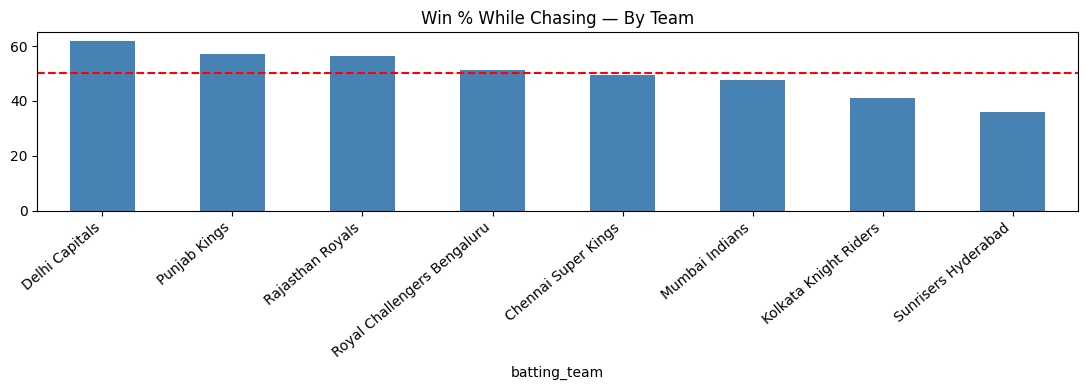

In [28]:
# .plot(kind='bar') creates a bar chart from the Series
win_pct.plot(kind='bar', figsize=(11, 4), color='steelblue')
# Add a title to the chart
plt.title('Win % While Chasing — By Team')
# Draw a horizontal red dashed line at 50% for reference
plt.axhline(50, color='red', linestyle='--', label='50%')
# Rotate x-axis labels so team names don't overlap
plt.xticks(rotation=40, ha='right')
# Automatically adjust spacing so nothing gets cut off
plt.tight_layout()
# Display the chart
plt.show()

In [29]:
# .to_csv() saves the DataFrame as a CSV file
# index=False means don't write the row numbers (0,1,2...) as a column
final_df.to_csv('IPL_processed_dataset.csv', index=False)
print('Saved processed_dataset.csv')
print('Rows:', len(final_df))
print()
print('✅ Day 1 complete! Download processed_dataset.csv before closing.')

Saved processed_dataset.csv
Rows: 18465

✅ Day 1 complete! Download processed_dataset.csv before closing.


In [31]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [32]:
df = pd.read_csv('/content/IPL_processed_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (18465, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,222.0,119.0,10.0,223.0,6.0,11.19,0
1,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,119.0,10.0,223.0,12.0,11.14,0
2,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,118.0,10.0,223.0,6.0,11.24,0
3,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220.0,117.0,10.0,223.0,6.0,11.28,0
4,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,219.0,116.0,10.0,223.0,6.0,11.33,0


#Training and Test split
}

In [33]:
X = df.drop('result', axis=1)
y = df['result']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42)
print('Training rows:', len(X_train))
print('Testing rows: ', len(X_test))

Training rows: 13848
Testing rows:  4617


In [35]:
CATEGORICAL = ['batting_team', 'bowling_team', 'city']
NUMERIC = ['runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr']
preprocessor = ColumnTransformer([
('cat', OneHotEncoder(
sparse_output=False,
drop='first',
handle_unknown='ignore'
), CATEGORICAL),
('num', StandardScaler(), NUMERIC)
])
pipe = Pipeline([
('step1', preprocessor),
('step2', LogisticRegression(solver='liblinear', max_iter=1000))
])
print('Pipeline built!')


Pipeline built!


In [36]:
pipe.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [37]:
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')


Accuracy: 85.68%


save model with pickle

In [38]:
pickle.dump(pipe, open('pipe.pkl', 'wb'))
print('Saved: pipe.pkl')
loaded = pickle.load(open('pipe.pkl', 'rb'))
verify_acc = accuracy_score(y_test, loaded.predict(X_test))
print(f'Reload accuracy: {verify_acc * 100:.2f}% ✓')

Saved: pipe.pkl
Reload accuracy: 85.68% ✓


In [39]:
import ipywidgets as widgets
from IPython.display import display
ALL_CITIES = sorted(df['city'].unique().tolist())
TEAMS = sorted(df['batting_team'].unique().tolist())
batting_team_widget = widgets.Dropdown(
options=TEAMS,
description='Batting Team:',
disabled=False,
continuous_update=False
)
bowling_team_widget = widgets.Dropdown(
options=TEAMS,
description='Bowling Team:',
disabled=False,
continuous_update=False
)
city_widget = widgets.Dropdown(
options=ALL_CITIES,
description='City:',
disabled=False,
continuous_update=False
)
runs_left_widget = widgets.IntText(
value=50,
description='Runs Left:',
disabled=False
)
balls_left_widget = widgets.IntText(
value=30,
description='Balls Left:',
disabled=False
)
wickets_remaining_widget = widgets.IntText(
value=7,
description='Wickets Remaining:',
disabled=False
)
runs_target_widget = widgets.IntText(
value=180,
description='Target Score:',
disabled=False
)
crr_widget = widgets.FloatText(
value=9.0,
description='Current RR:',
disabled=False
)
rrr_widget = widgets.FloatText(
value=10.0,
description='Required RR:',
disabled=False
)
predict_button = widgets.Button(description='Predict Win Probability')
output_widget = widgets.Output()
display(
batting_team_widget, bowling_team_widget, city_widget,
runs_left_widget, balls_left_widget, wickets_remaining_widget,
runs_target_widget, crr_widget, rrr_widget,
predict_button, output_widget
)

Dropdown(description='Batting Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders…

Dropdown(description='Bowling Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Kolkata Knight Riders…

Dropdown(description='City:', options=('Ahmedabad', 'Bangalore', 'Bloemfontein', 'Cape Town', 'Centurion', 'Ch…

IntText(value=50, description='Runs Left:')

IntText(value=30, description='Balls Left:')

...

IntText(value=180, description='Target Score:')

FloatText(value=9.0, description='Current RR:')

FloatText(value=10.0, description='Required RR:')

Button(description='Predict Win Probability', style=ButtonStyle())

Output()

In [44]:
def on_predict_button_clicked(b):
  with output_widget:
    output_widget.clear_output()
    try:
        input_data = pd.DataFrame({
            'batting_team': [batting_team_widget.value],
            'bowling_team': [bowling_team_widget.value],
            'city': [city_widget.value],
            'runs_left': [runs_left_widget.value],
            'balls_left': [balls_left_widget.value],
            'wickets_remaining': [wickets_remaining_widget.value],
            'runs_target': [runs_target_widget.value],
            'crr': [crr_widget.value],
            'rrr': [rrr_widget.value]
        })
        prediction = pipe.predict_proba(input_data)
        win_prob_batting_team = round(prediction[0][1] * 100, 2)
        win_prob_bowling_team = round(prediction[0][0] * 100, 2)
        print(f'{batting_team_widget.value} Win Probability: {win_prob_batting_team}%')
        print(f'{bowling_team_widget.value} Win Probability: {win_prob_bowling_team}%')
    except Exception as e:
        print(f"An error occurred: {e}")
predict_button.on_click(on_predict_button_clicked)